# No debt simulation
The agents exchange a fixed amount of money and debt is not allowed.


In [23]:
import functions as func
import matplotlib.pyplot as plt
import numpy as np



In [24]:
N = 3500
M = 10e5
steps = 10e5
gamma = 0.33


agents = func.simulate_proportional_money_transfer(N=N, M=M, steps=steps, gamma = gamma)

print(f"Shape: {agents.shape}")
print(f"Total money: {agents.sum():.2f}")
print(f"Minimum: {agents.min():.2f}")
print(f"Maximum: {agents.max():.2f}")
print("First 10 agents:", agents[:10])

Shape: (3500,)
Total money: 1000000.00
Minimum: 3.85
Maximum: 1494.11
First 10 agents: [520.07862336 111.24189868   7.12923773  79.86387873 179.00774188
 136.97784012 200.51265146 309.85302409 127.85165301 349.87397988]


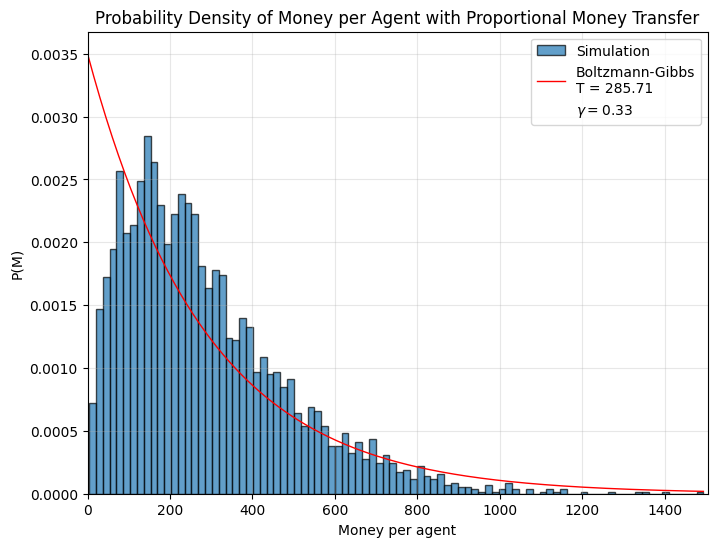

In [32]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

T = M / N

fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(
    agents,
    bins=90,
    density=True,
    alpha=0.7,
    edgecolor="black",
    label="Simulation"
)

x_fit = np.linspace(0, agents.max(), 300)
y_fit = (1 / T) * np.exp(-x_fit / T)

plt.plot(
    x_fit,
    y_fit,
    "r-",
    linewidth=1,
    label=f"Boltzmann-Gibbs\nT = {T:.2f}"
)

plt.xlabel("Money per agent")
plt.ylabel("P(M)")
plt.title("Probability Density of Money per Agent with Proportional Money Transfer")
plt.legend()
ax.plot([], [], " ", label=rf"$\gamma = {gamma:.2f}$")
ax.legend()
plt.grid(alpha=0.3)
plt.xlim(0, agents.max() + 10)
plt.show()

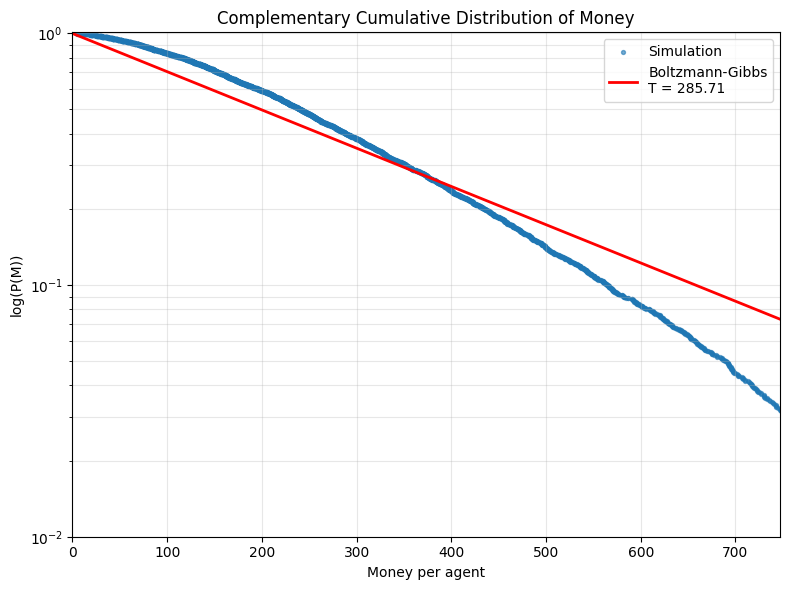

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))

sorted_agents = np.sort(agents)
probability = 1 - np.arange(1, N + 1) / N  # complementary cumulative probability

ax.scatter(
    sorted_agents,
    probability,
    s=8,
    alpha=0.6,
    label="Simulation"
)

ax.plot(
    x_fit,
    np.exp(-x_fit / T),
    "r-",
    linewidth=2,
    label=f"Boltzmann-Gibbs\nT = {T:.2f}"
)

ax.set_yscale("log")
ax.set_xlabel("Money per agent")
ax.set_ylabel("log(P(M))")
ax.set_title("Complementary Cumulative Distribution of Money")
ax.legend()
ax.grid(which="both", alpha=0.3)
#ax.set_xlim(0, agents.max())
ax.set_xlim(0, agents.max()/2)
ax.set_ylim(1e-2, 1.01)  # Set y-axis limits for better visibility

plt.tight_layout()
plt.show()

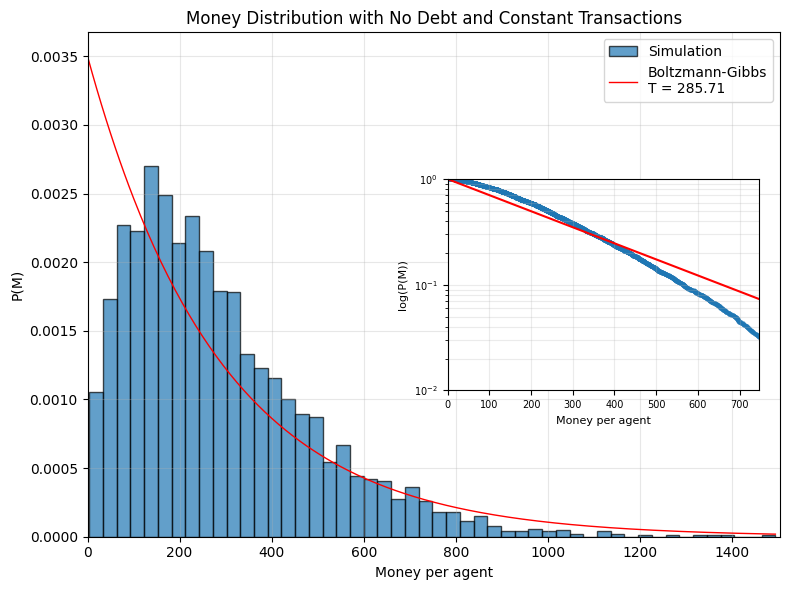

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))

# First plot: histogram and Boltzmann-Gibbs distribution
ax.hist(
    agents,
    bins=50,
    density=True,
    alpha=0.7,
    edgecolor="black",
    label="Simulation"
)

ax.plot(
    x_fit,
    y_fit,
    "r-",
    linewidth=1,
    label=f"Boltzmann-Gibbs\nT = {T:.2f}"
)

ax.set_xlabel("Money per agent")
ax.set_ylabel("P(M)")
ax.set_title("Money Distribution with No Debt and Constant Transactions")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
ax.set_xlim(0, agents.max() + 10)

# Second plot as a small overlay, centered vertically and shifted right
inset = ax.inset_axes([0.52, 0.29, 0.45, 0.42])

inset.scatter(
    sorted_agents,
    probability,
    s=5,
    alpha=0.6,
    color="tab:blue"
)

inset.plot(
    x_fit,
    np.exp(-x_fit / T),
    "r-",
    linewidth=1.5
)

inset.set_yscale("log")
inset.set_xlim(0, agents.max() / 2)
inset.set_ylim(1e-2, 1.01)
inset.set_xlabel("Money per agent", fontsize=8)
inset.set_ylabel("log(P(M))", fontsize=8)
inset.tick_params(axis="both", labelsize=7)
inset.grid(which="both", alpha=0.25)

plt.tight_layout()
plt.show()